In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from PIL import Image
from collections import Counter
warnings.filterwarnings('ignore')

In [3]:
BASE_PATH = '../dog-breed-identification/dog-breed-identification/'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
LABELS_PATH = os.path.join(BASE_PATH, 'labels.csv')


In [4]:
labels_df = pd.read_csv(LABELS_PATH)
print(len(labels_df))
print(labels_df['breed'].nunique())

10222
120


In [5]:
labels_df.head(120)

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever
...,...,...
115,02c90d8109d9a48739b9887349d92b1f,airedale
116,02cc0d7c8b7b513b4325bda30dce222d,brittany_spaniel
117,02d45a238621c3f2cbde5c1d173ead1e,bull_mastiff
118,02d54f0dfb40038765e838459ae8c956,bernese_mountain_dog


In [6]:
breed_counts = labels_df['breed'].value_counts()
all_breeds = breed_counts.index.tolist()

In [12]:
print(f"Total Breeds: {len(all_breeds)}")
print(f"Top 20 Most Frequent Breeds:")
for i, (breed, count) in enumerate(breed_counts.head(20).items(), 1):
    print(f"{i:2d}. {breed:30s} - {count:4d} images")

Total Breeds: 120
Top 20 Most Frequent Breeds:
 1. scottish_deerhound             -  126 images
 2. maltese_dog                    -  117 images
 3. afghan_hound                   -  116 images
 4. entlebucher                    -  115 images
 5. bernese_mountain_dog           -  114 images
 6. shih-tzu                       -  112 images
 7. great_pyrenees                 -  111 images
 8. pomeranian                     -  111 images
 9. basenji                        -  110 images
10. samoyed                        -  109 images
11. airedale                       -  107 images
12. tibetan_terrier                -  107 images
13. leonberg                       -  106 images
14. cairn                          -  106 images
15. beagle                         -  105 images
16. japanese_spaniel               -  105 images
17. australian_terrier             -  102 images
18. blenheim_spaniel               -  102 images
19. miniature_pinscher             -  102 images
20. irish_wolfhound   

In [13]:
print(f"Total Breeds: {len(all_breeds)}")
print(f"Top 20 Least Frequent Breeds:")
for i, (breed, count) in enumerate(breed_counts.tail(20).items(), 1):
    print(f"{i:2d}. {breed:30s} - {count:4d} images")

Total Breeds: 120
Top 20 Least Frequent Breeds:
 1. standard_schnauzer             -   72 images
 2. curly-coated_retriever         -   72 images
 3. flat-coated_retriever          -   72 images
 4. border_collie                  -   72 images
 5. redbone                        -   72 images
 6. kuvasz                         -   71 images
 7. chihuahua                      -   71 images
 8. soft-coated_wheaten_terrier    -   71 images
 9. french_bulldog                 -   70 images
10. vizsla                         -   70 images
11. otterhound                     -   69 images
12. german_shepherd                -   69 images
13. walker_hound                   -   69 images
14. tibetan_mastiff                -   69 images
15. giant_schnauzer                -   69 images
16. golden_retriever               -   67 images
17. brabancon_griffon              -   67 images
18. komondor                       -   67 images
19. eskimo_dog                     -   66 images
20. briard           

In [14]:
with open('all_breeds.pkl', 'wb') as f:
    pickle.dump(all_breeds, f)

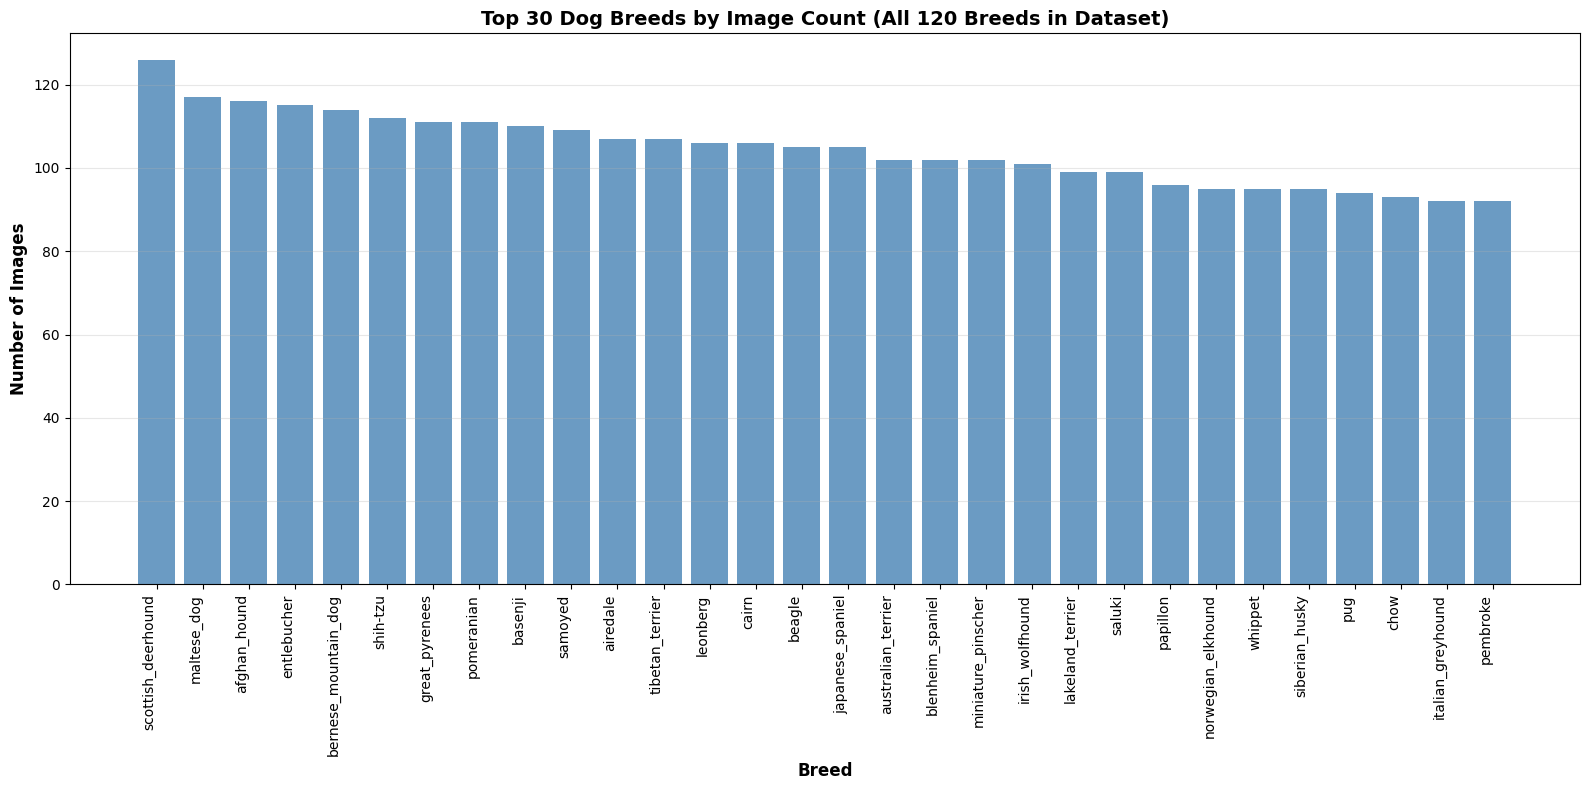

In [15]:
plt.figure(figsize=(16, 8))
top_30 = breed_counts.head(30)
bars = plt.bar(range(len(top_30)), top_30.values, color='steelblue', alpha=0.8)
plt.xticks(range(len(top_30)), top_30.index, rotation=90, ha='right')
plt.xlabel('Breed', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Top 30 Dog Breeds by Image Count (All 120 Breeds in Dataset)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('breed_distribution_top30.png', dpi=300, bbox_inches='tight')
plt.show()

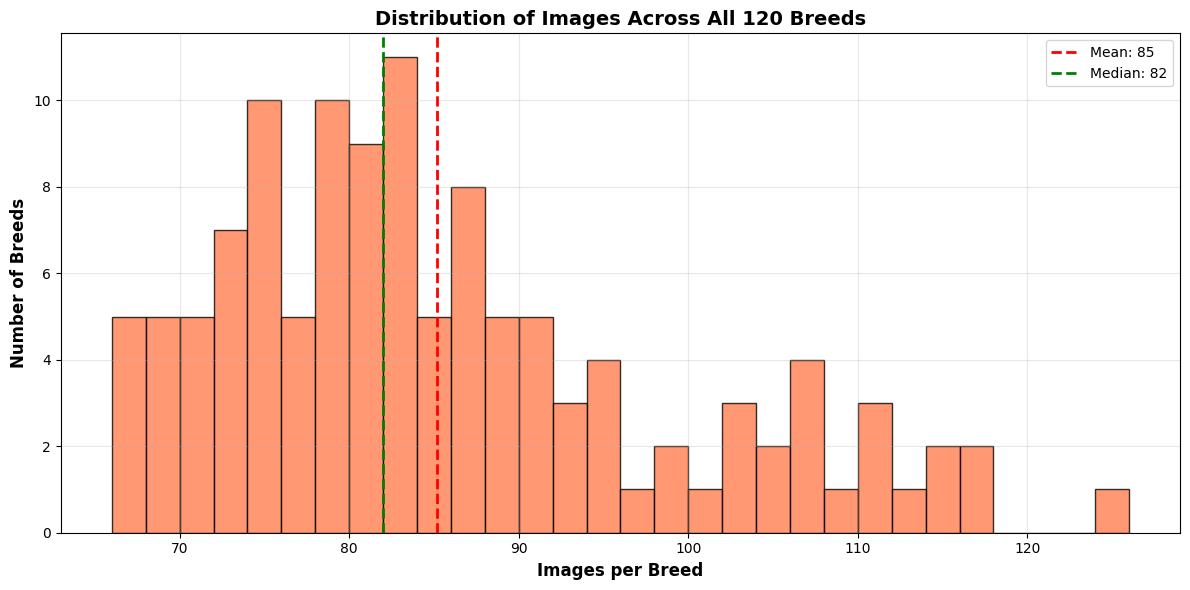

In [16]:
plt.figure(figsize=(12, 6))
plt.hist(breed_counts.values, bins=30, color='coral', alpha=0.8, edgecolor='black')
plt.axvline(breed_counts.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {breed_counts.mean():.0f}')
plt.axvline(breed_counts.median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {breed_counts.median():.0f}')
plt.xlabel('Images per Breed', fontsize=12, fontweight='bold')
plt.ylabel('Number of Breeds', fontsize=12, fontweight='bold')
plt.title('Distribution of Images Across All 120 Breeds', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images_per_breed_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print(f"Dataset Statistics:")
print(f"Total images: {len(labels_df)}")
print(f"Number of breeds: {labels_df['breed'].nunique()}")
print(f"Images per breed (min): {breed_counts.min()}")
print(f"Images per breed (max): {breed_counts.max()}")
print(f"Images per breed (mean): {breed_counts.mean():.2f}")
print(f"Images per breed (median): {breed_counts.median():.2f}")
print(f"Images per breed (std): {breed_counts.std():.2f}")

Dataset Statistics:
Total images: 10222
Number of breeds: 120
Images per breed (min): 66
Images per breed (max): 126
Images per breed (mean): 85.18
Images per breed (median): 82.00
Images per breed (std): 13.30


In [20]:
sample_size = min(1000, len(labels_df))
sample_ids = np.random.choice(labels_df['id'].values, sample_size, replace=False)

widths, heights, aspect_ratios, corrupted = [], [], [], []

for img_id in sample_ids:
    try:
        img_path = os.path.join(TRAIN_PATH, f"{img_id}.jpg")
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
    except:
        corrupted.append(img_id)

print(f"✓ Successfully analyzed {len(widths)} images")
if corrupted:
    print(f"⚠ Found {len(corrupted)} corrupted/problematic images")

print(f"\nImage Size Statistics:")
print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")
print(f"  Aspect Ratio - Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}, Mean: {np.mean(aspect_ratios):.2f}")


✓ Successfully analyzed 1000 images

Image Size Statistics:
  Width  - Min: 111, Max: 3264, Mean: 443
  Height - Min: 133, Max: 2448, Mean: 390
  Aspect Ratio - Min: 0.42, Max: 2.32, Mean: 1.18


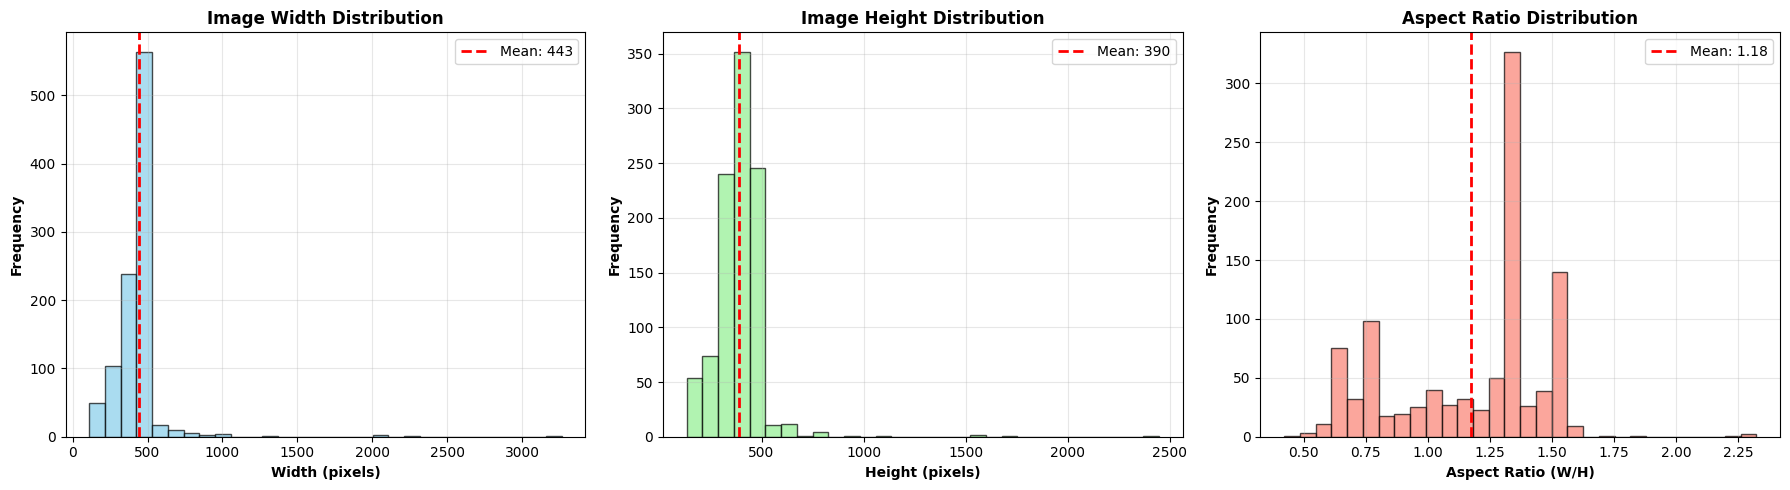

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(widths), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(widths):.0f}')
axes[0].set_xlabel('Width (pixels)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(heights), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(heights):.0f}')
axes[1].set_xlabel('Height (pixels)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(aspect_ratios, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[2].axvline(np.mean(aspect_ratios), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[2].set_xlabel('Aspect Ratio (W/H)', fontweight='bold')
axes[2].set_ylabel('Frequency', fontweight='bold')
axes[2].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('image_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

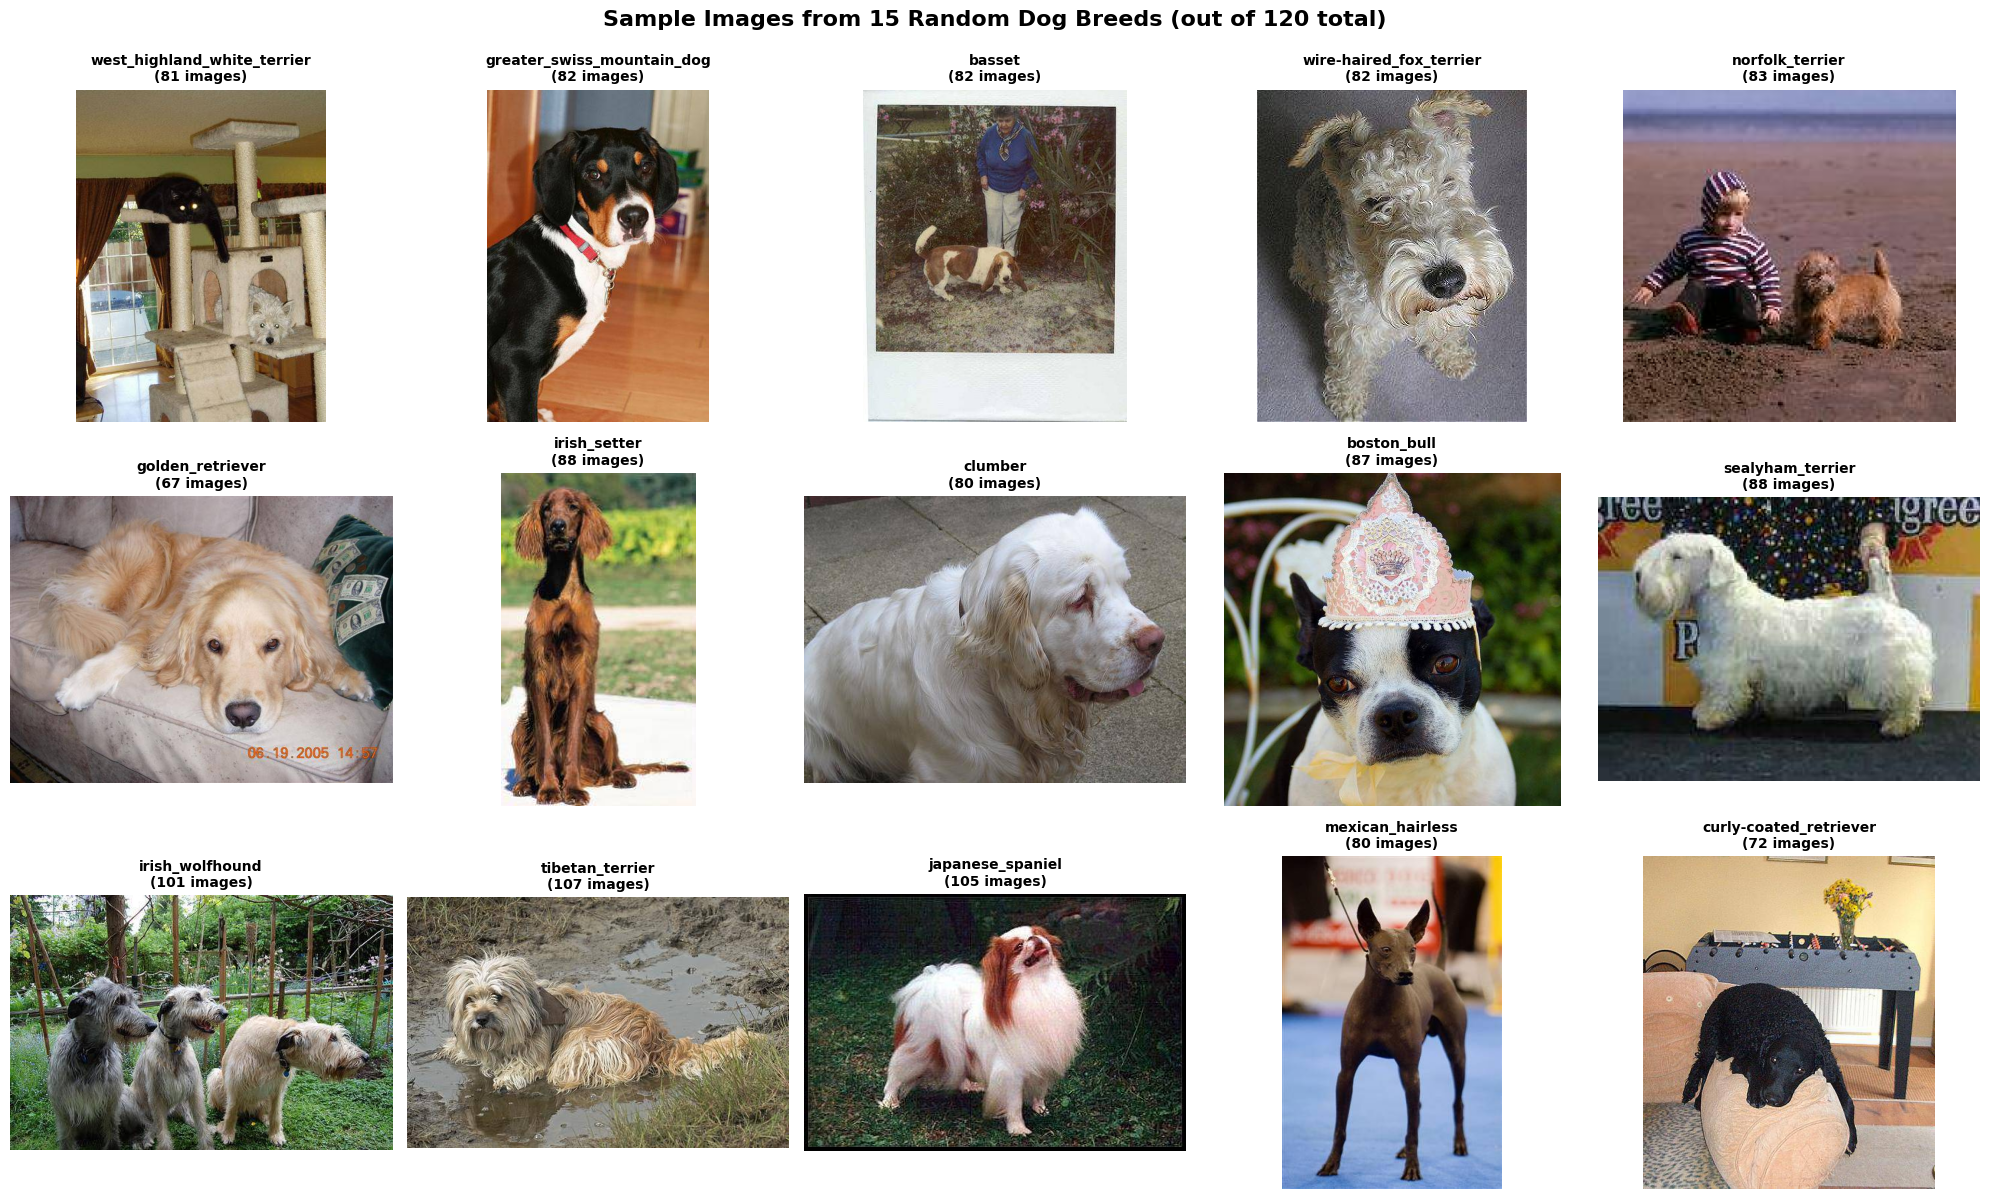

In [22]:
random_breeds = np.random.choice(all_breeds, 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for idx, breed in enumerate(random_breeds):
    breed_images = labels_df[labels_df['breed'] == breed]['id'].values
    sample_id = np.random.choice(breed_images)
    
    img_path = os.path.join(TRAIN_PATH, f"{sample_id}.jpg")
    try:
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{breed}\n({len(breed_images)} images)", 
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, 'Image Error', ha='center', va='center')
        axes[idx].set_title(breed, fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Sample Images from 15 Random Dog Breeds (out of 120 total)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('sample_images_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
max_count = breed_counts.max()
min_count = breed_counts.min()
balance_ratio = max_count / min_count

print(f"\nClass Balance Metrics:")
print(f"  Most common breed: {breed_counts.index[0]} ({max_count} images)")
print(f"  Least common breed: {breed_counts.index[-1]} ({min_count} images)")
print(f"  Balance ratio (max/min): {balance_ratio:.2f}")

if balance_ratio < 2.0:
    print("  ✓ Dataset is well-balanced")
elif balance_ratio < 3.0:
    print("  ⚠ Dataset has moderate imbalance - consider class weights")
else:
    print("  ⚠ Dataset has significant imbalance - MUST use class weights")


Class Balance Metrics:
  Most common breed: scottish_deerhound (126 images)
  Least common breed: briard (66 images)
  Balance ratio (max/min): 1.91
  ✓ Dataset is well-balanced


In [21]:
summary = {
    "total_images": len(labels_df),
    "num_breeds": labels_df['breed'].nunique(),
    "min_images_per_breed": int(breed_counts.min()),
    "max_images_per_breed": int(breed_counts.max()),
    "mean_images_per_breed": float(breed_counts.mean()),
    "std_images_per_breed": float(breed_counts.std()),
    "balance_ratio": float(balance_ratio),
    "mean_width": float(np.mean(widths)),
    "mean_height": float(np.mean(heights)),
    "mean_aspect_ratio": float(np.mean(aspect_ratios)),
    "corrupted_images": len(corrupted)
}
print(summary)

pd.DataFrame([summary]).to_csv("eda_summary_all.csv", index=False)

{'total_images': 10222, 'num_breeds': 120, 'min_images_per_breed': 66, 'max_images_per_breed': 126, 'mean_images_per_breed': 85.18333333333334, 'std_images_per_breed': 13.298122274306587, 'balance_ratio': 1.9090909090909092, 'mean_width': 440.343, 'mean_height': 387.174, 'mean_aspect_ratio': 1.174259060706409, 'corrupted_images': 0}
